In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

options(repr.plot.width = 10)

In [2]:
novelties = c(0.5, 0.95, 1.25)
communities = paste0('marine', seq(0, length(novelties) - 1), "novelty", novelties)
d1a = data.table(expand.grid(community = communities,
                             ts = c(0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5),
                             mask = seq(0, 4)))
d1a[, `:=`(tg = ts, tf = ts, to = ts, tc = ts, tp = ts, td = ts, tr = ts, seta = 1)]
d1r = data.table(expand.grid(community = communities,
                             ts = 0.3, tg = 0.3, tf = 0.3, to = 0.3, tc = 0.3,
                             tp = 0.3, td = 0.3, tr = c(0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0),
                             mask = seq(0, 4), setr = 1))
d1ar = merge(d1a, d1r, all = TRUE)
d1d = data.table(expand.grid(community = communities,
                             ts = 0.3, tg = 0.3, tf = 0.3, to = 0.3, tc = 0.3,
                             tp = 0.3, td = c(0.3, 0.4, 0.5, 0.6, 0.8, 1.0),
                             tr = 3.1,
                             mask = seq(0, 4), setd = 1))
d1d[, tr := round(tr - td - tp - tc - to - tf - tg - ts, 5)]
d1p = data.table(expand.grid(community = communities,
                             ts = 0.3, tg = 0.3, tf = 0.3, to = 0.3, tc = 0.3,
                             tp = c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6), td = 2.8,
                             tr = 3.1,
                             mask = seq(0, 4), setp = 1))
d1p[, td := round(td - tp - tc - to - tf - tg - ts, 5)]
d1p[, tr := round(tr - td - tp - tc - to - tf - tg - ts, 5)]
d1 = merge(merge(d1ar, d1d, all = TRUE), d1p, all = TRUE)
dim(d1)
d1[seta == 1 & setr == 1]
d1[setr == 1][1:5]

[1] 390  14

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine0novelty0.5,0.3,1,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine0novelty0.5,0.3,2,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine0novelty0.5,0.3,3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine0novelty0.5,0.3,4,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine1novelty0.95,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine1novelty0.95,0.3,1,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine1novelty0.95,0.3,2,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine1novelty0.95,0.3,3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA


community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.5,NA,1,NA,NA
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.8,NA,1,NA,NA
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,1.0,NA,1,1,NA
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,1.2,NA,1,NA,NA


In [3]:
readit = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    ff <- function(x) format(x, nsmall = 1)
    to_read = paste0('output_singlem_dev/opal/tune_s', ff(ts), 'g', ff(tg),
                     'f', ff(tf), 'o', ff(to), 'c', ff(tc),
                     'p', ff(tp), 'd', ff(td), 'r', ff(tr),
                     'mask', mask, '/', community,'.opal_report')
    #if (!file.exists(to_read)) return()
    return(fread(to_read))
}
d2 = d1[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by = d1]

In [4]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readit(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
dim(d2)
d2[1:5,]

[1] 70154    19

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,tool,rank,metric,sample,value
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,Gold standard,kingdom,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,Gold standard,phylum,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,Gold standard,class,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,Gold standard,order,Bray-Curtis distance,SAMPLEID,0
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,Gold standard,family,Bray-Curtis distance,SAMPLEID,0


In [5]:
s1 = d2[tool != "Gold standard" & metric == "Bray-Curtis distance"]
s1[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]
setnames(s1, "value", "Bray-Curtis distance")

In [6]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
plot_bc <- function(data) {
   ggplot(data, aes(rank, `Bray-Curtis distance`)) +
      geom_boxplot() +
      scale_x_discrete(na.translate = FALSE) +
      theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
      theme(legend.title=element_blank()) +
      theme(legend.position=c(0.1,0.4)) +
      theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

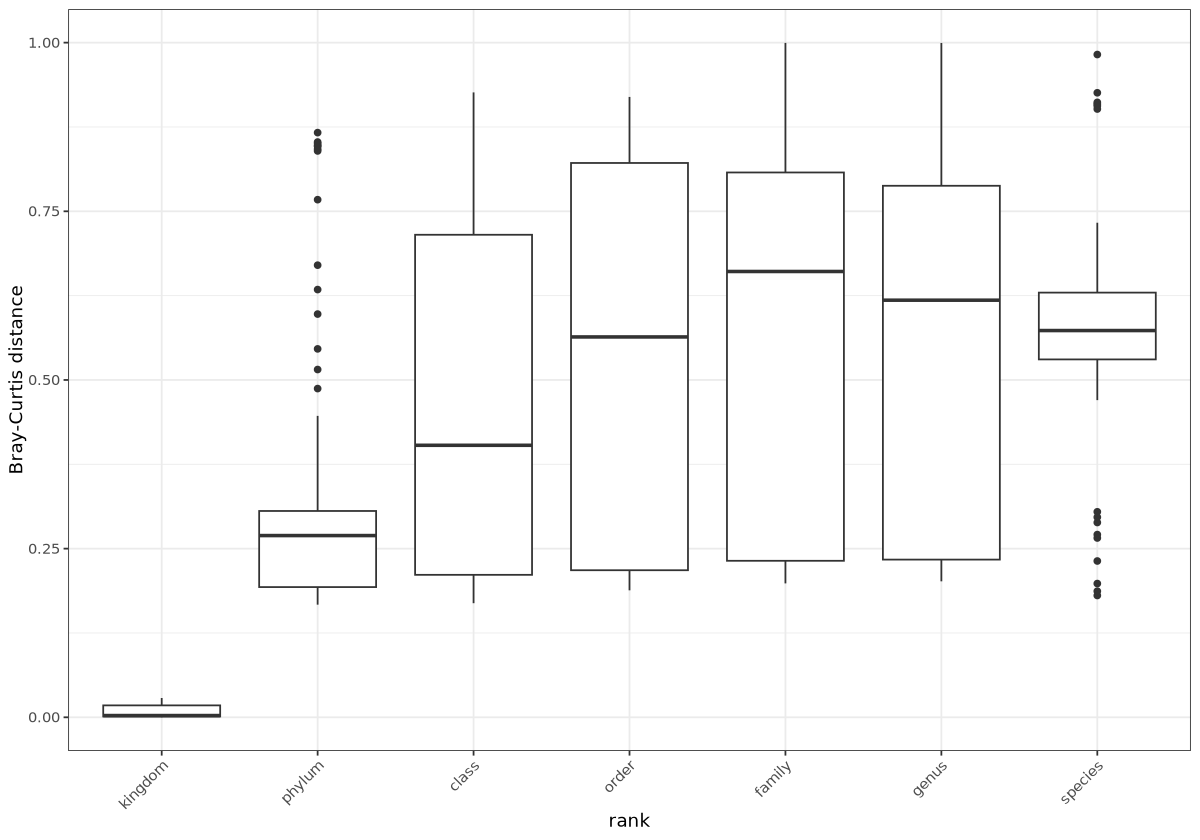

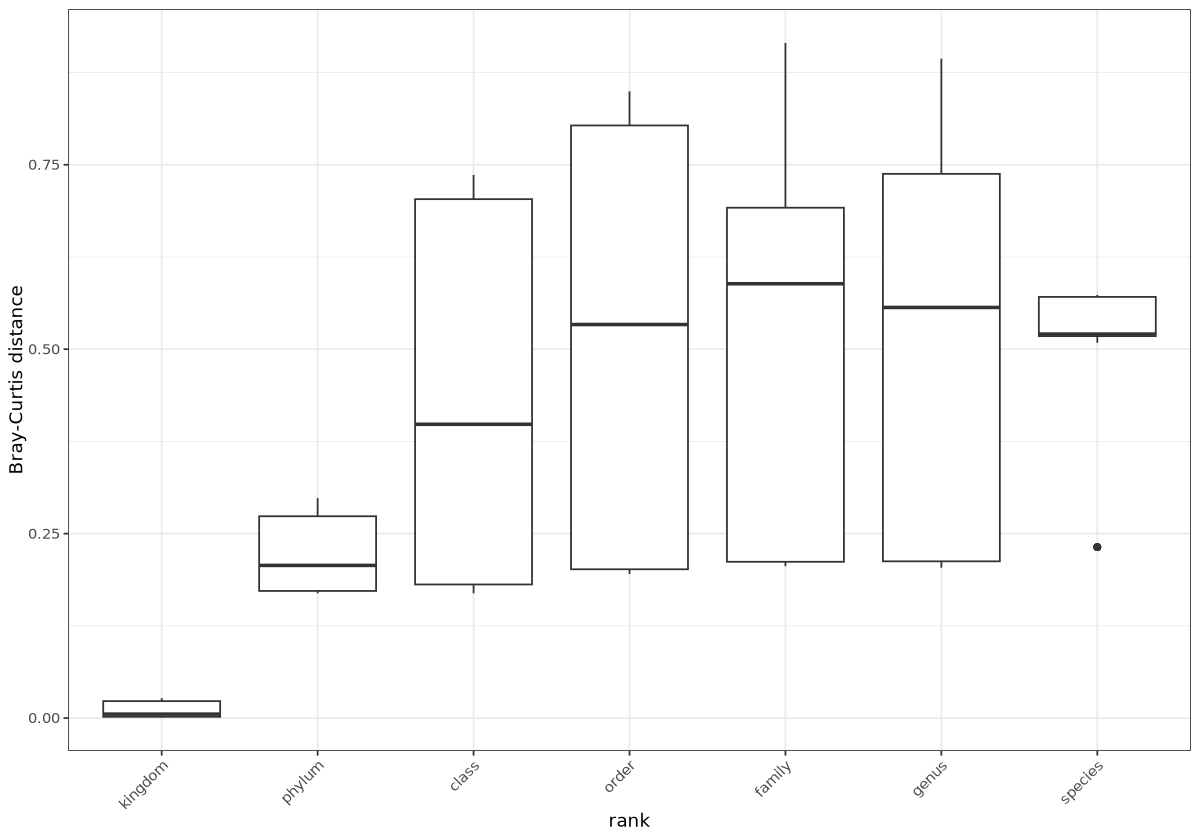

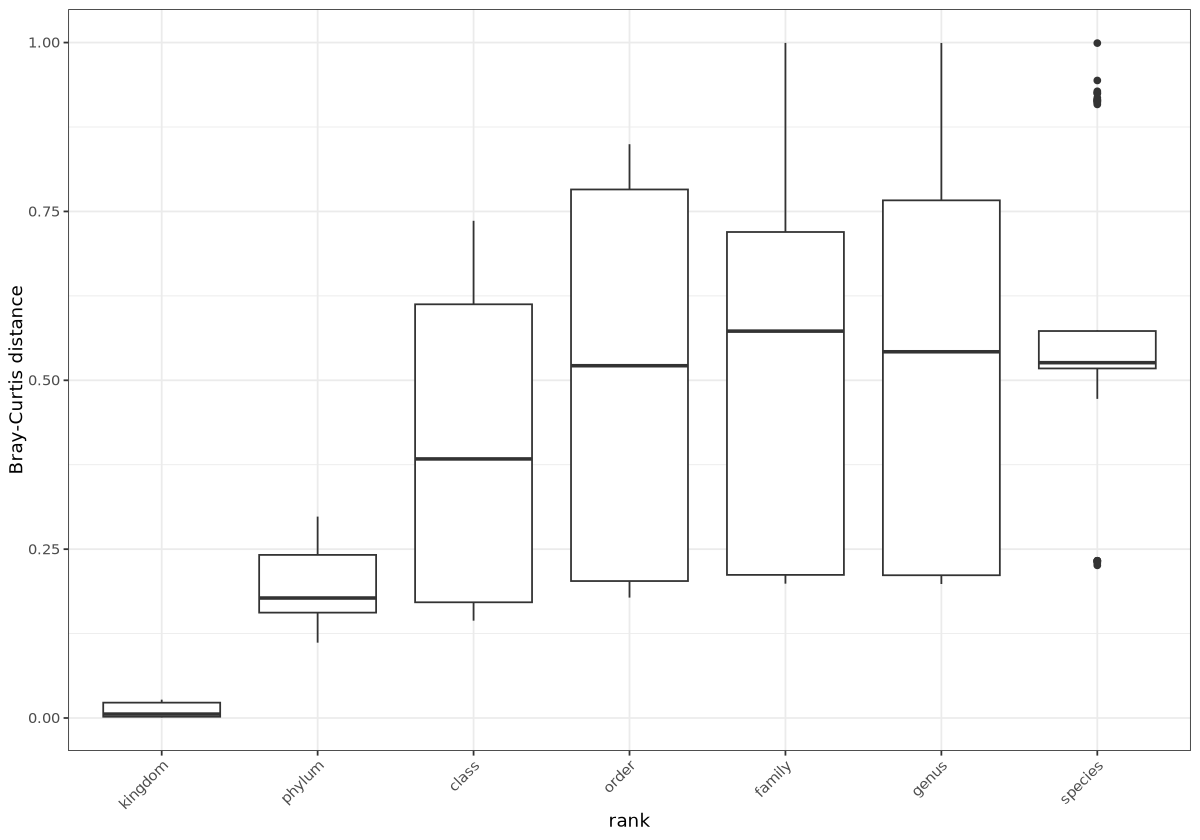

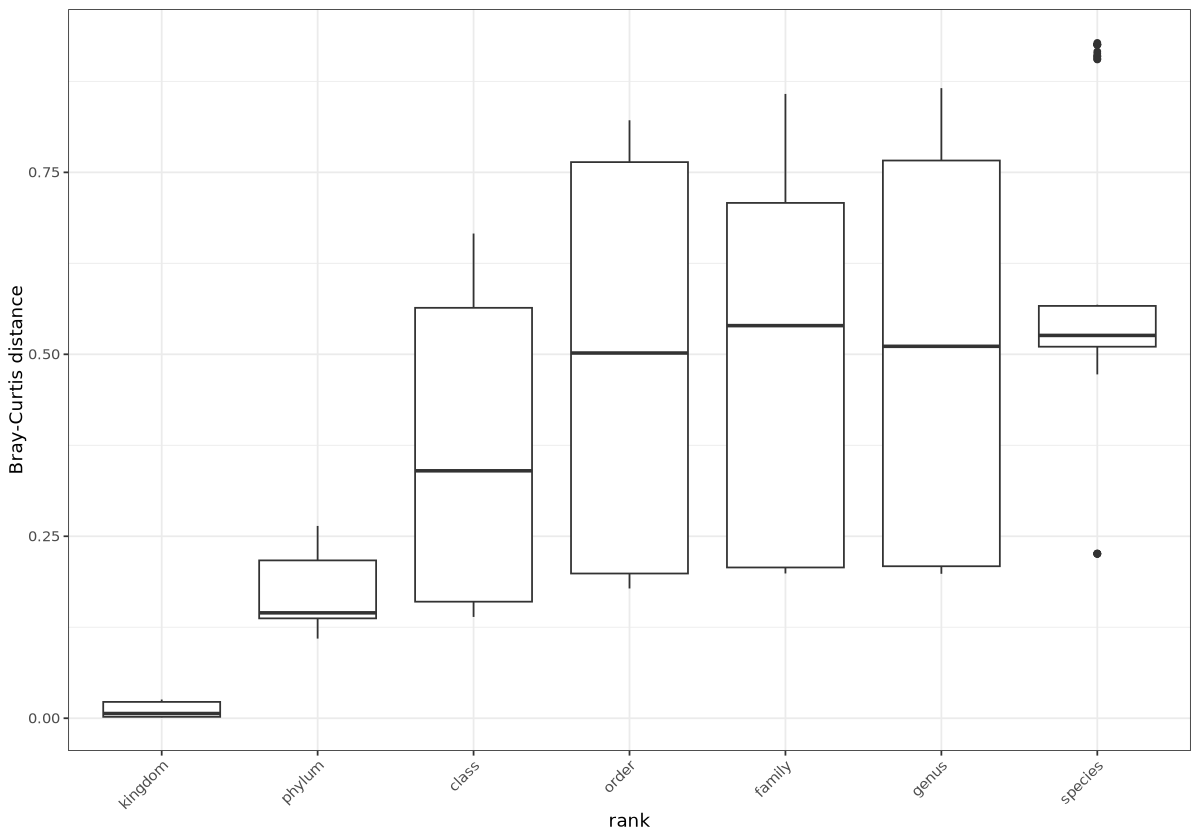

In [7]:
plot_bc(s1[seta == 1])
plot_bc(s1[setr == 1])
plot_bc(s1[setd == 1])
plot_bc(s1[setp == 1])

# NMF penalty tuning

In [8]:
readloss = function(community, ts, tg, tf, to, tc, tp, td, tr, mask){
    ff <- function(x) format(x, nsmall = 1)
    to_read = paste0('output_singlem_dev/singlem_dev/tune_s', ff(ts), 'g', ff(tg),
                     'f', ff(tf), 'o', ff(to), 'c', ff(tc),
                     'p', ff(tp), 'd', ff(td), 'r', ff(tr),
                     'mask', mask, '/', community,'.loss.tsv')
    #if (!file.exists(to_read)) return()
    return(fread(to_read, header = FALSE, col.names = c("metric", "value")))
}
d3 = d1[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
        by=d1]

In [9]:
#d2 = data.table(community = communities[1], ts = 0.1, tg = 0,
#                tf = 0, to = 0, tc = 0, tp = 0, td = 0, tr = 0,
#                mask = 0)[, readloss(community, ts, tg, tf, to, tc, tp, td, tr, mask),
#                          by = list(community, ts, tg, tf, to, tc, tp, td, tr, mask)]
d3[1:5,]

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,41.386
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF mask loss,113.952
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF penalised loss,49.203
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF steps,4826.000
marine0novelty0.5,0.01,1,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,45.527


In [10]:
s1_bcr = s1[, names(s1)[!names(s1) %in% c("metric", "tool", "sample")], with = FALSE]
s1_bcr[, c("metric", "rank", "value", "Bray-Curtis distance") := list(paste0("BC ", rank), NULL, `Bray-Curtis distance`, NULL)]
d4 = rbind(d3, s1_bcr)
d4[1:5]

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,41.386
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF mask loss,113.952
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF penalised loss,49.203
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF steps,4826.000
marine0novelty0.5,0.01,1,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,45.527


In [11]:
d4_steps = d4[metric == "NMF steps"]
d4_steps[, metric := NULL]
setnames(d4_steps, "value", "steps")
d5 = d4[!metric %in% c("NMF steps", "NMF penalised loss"), ][d4_steps, on = .NATURAL]
d5[1:5]

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value,steps
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,41.38600000,4826
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF mask loss,113.95200000,4826
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC kingdom,0.02157301,4826
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC phylum,0.20689551,4826
marine0novelty0.5,0.01,0,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC class,0.20689551,4826


In [12]:
d5[setr == 1 & ts == 0.3][1:5]

community,ts,mask,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value,steps
<fct>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,NMF loss,72.60500000,501
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,NMF mask loss,112.87700000,501
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC kingdom,0.02712425,501
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC phylum,0.16914700,501
marine0novelty0.5,0.3,0,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC class,0.16914700,501


In [13]:
s2 = d5[,
        list(value = sum(value), steps = max(steps)),
        by = d5[, -c("value", "steps", "mask")]]
s2[metric == "NMF loss", value := value / 4]
s2[startsWith(metric, "BC"), value := value / 5]
s2[1:5]

community,ts,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF loss,53.14900000,5001
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,NMF mask loss,543.68300000,5001
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC kingdom,0.01811362,5001
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC phylum,0.26005395,5001
marine0novelty0.5,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,1,NA,NA,NA,BC class,0.26005395,5001


In [14]:
s2[setr == 1][1:5]

community,ts,tg,tf,to,tc,tp,td,tr,seta,setr,setd,setp,metric,value,steps
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
marine0novelty0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,NMF loss,91.42775000,2858
marine0novelty0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,NMF mask loss,534.85800000,2858
marine0novelty0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC kingdom,0.02231515,2858
marine0novelty0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC phylum,0.17269296,2858
marine0novelty0.5,0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3,1,1,NA,NA,BC class,0.17545569,2858


In [15]:
scale <- function(data) {
    data[, `:=`(min = min(value), max = max(value)), by = list(community, metric)]
    data[, value := ifelse(min == max, 0.5, (value - min) / (max - min))]
}
plot_slope <- function(data) {
    ggplot(data, aes(1/ts, value, colour = metric,
                     alpha = steps < 5000, group = metric)) +
    geom_point() +
    geom_line() +
    #scale_x_continuous(transform = scales::transform_reciprocal()) +
    facet_wrap(vars(community), scales = "free_y") +
    theme(legend.title=element_blank()) +
    theme(legend.position="bottom") +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


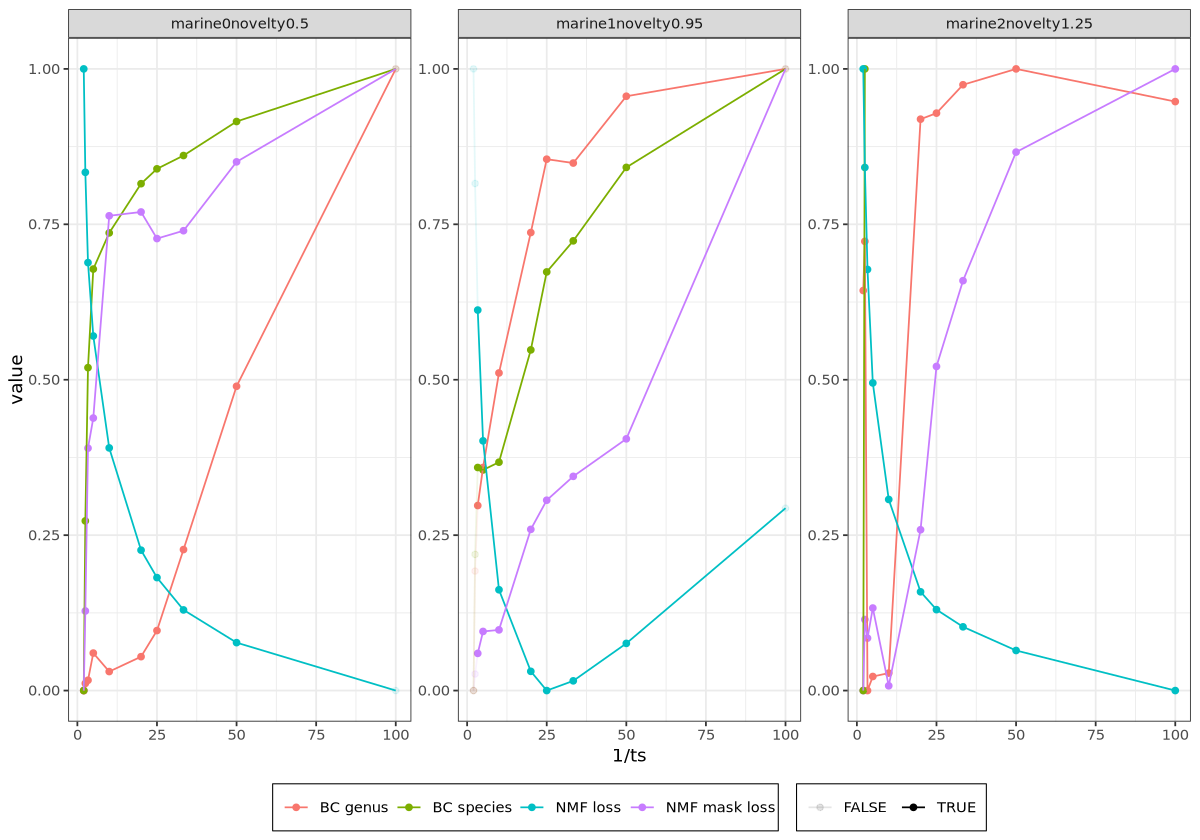

In [16]:
plot_slope(scale(s2[seta == 1 & (endsWith(metric, "species") | endsWith(metric, "genus") | !startsWith(metric, "BC"))]))

In [17]:
make_groups <- function(d1, ranks) {
    tunecols = c("ts", "tg", "tf", "to", "tc", "tp", "td", "tr")
    for (i in seq(2, length(tunecols))) {
        d1[, c(tunecols[i]) := list(round(d1[[tunecols[i]]] + d1[[tunecols[i-1]]], 5))]
    }
    tc_facts <- d1[, lapply(.SD, \(x) factor(x, levels = unique(sort(x)))), .SDcols = tunecols]
    for (c in ranks) {
        d1[, c(paste0("g_", c)) := list(interaction(tc_facts[, which(tunecols != c), with = FALSE], sep = ","))]
    }
    d1
}
plot_rank <- function(data, rank) {
    #data[["group"]] <- interaction(data[, c(paste0("g_", rank), "metric"), with = FALSE])
    data[["col"]] <- data[[paste0("g_", rank)]]
    ggplot(data, aes(1/.data[[rank]], value, colour = metric,
                     alpha = factor(steps < 5000, c(FALSE, TRUE)),
                     group = metric)) +
    geom_point() +
    geom_line() +
    scale_alpha_discrete(drop = FALSE) +
    facet_grid(vars(community), vars(col)) +
    theme(legend.title=element_blank()) +
    theme(legend.position="bottom") +
    #theme(legend.position=c(0.1,0.4)) +
    theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
    theme(strip.text.x = element_text(size = 8))
}

Warning message:
“Using alpha for a discrete variable is not advised.”


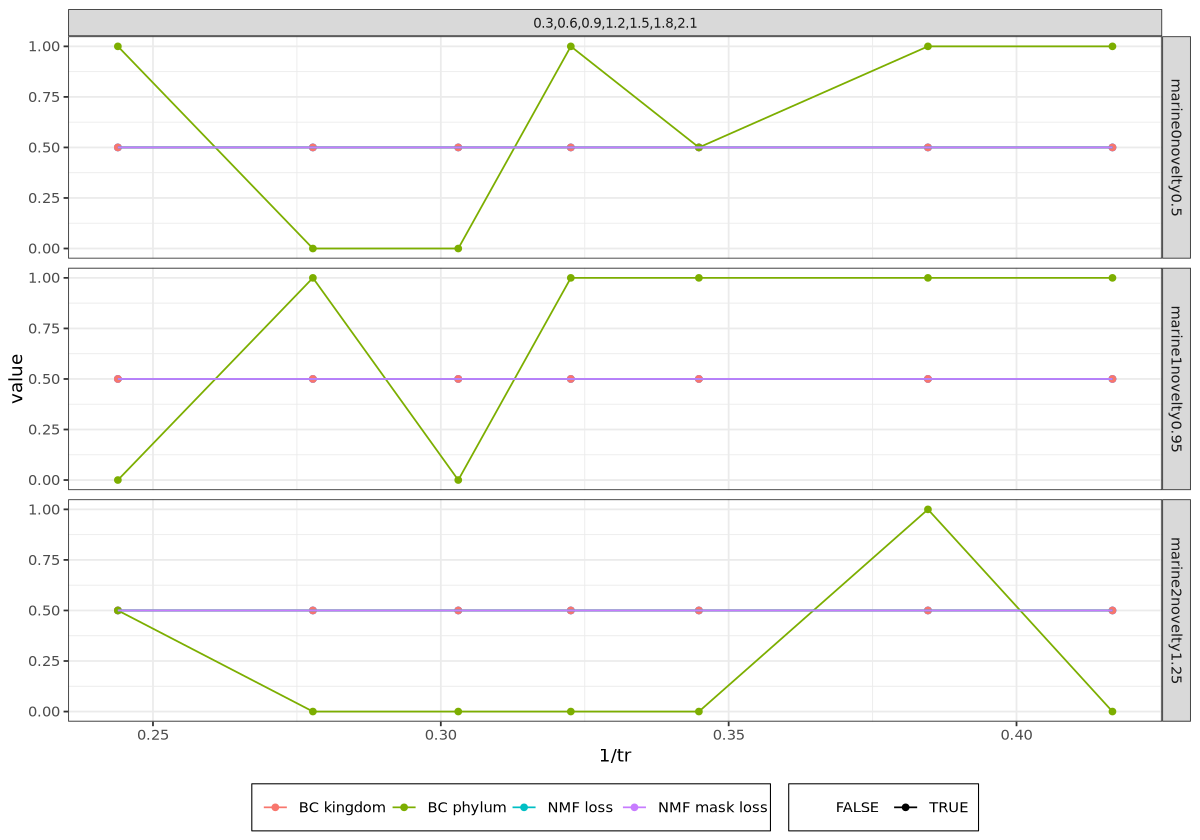

In [18]:
s2r = make_groups(scale(s2[setr == 1 & (!startsWith(metric, "BC") | endsWith(metric, "kingdom") | endsWith(metric, "phylum"))]), "tr")
plot_rank(s2r, "tr")

Warning message:
“Using alpha for a discrete variable is not advised.”


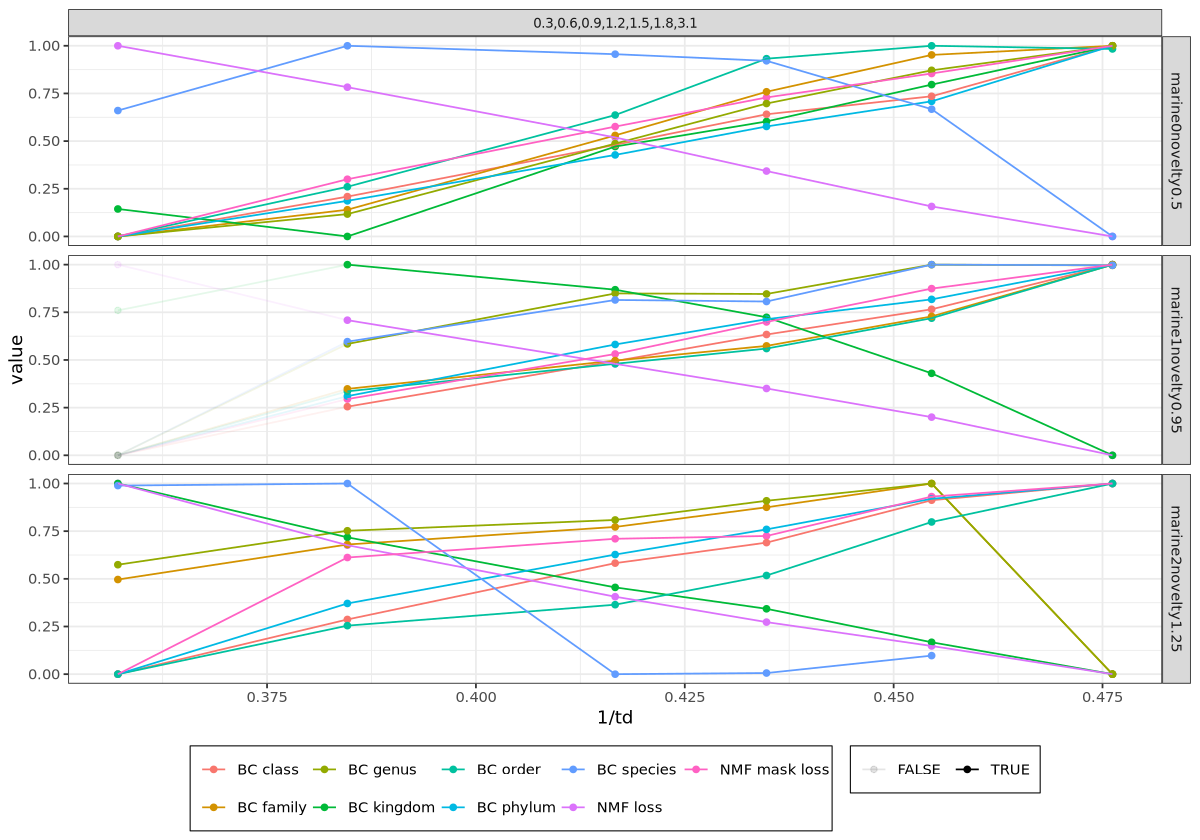

In [19]:
s2d = make_groups(scale(s2[setd == 1 & (TRUE | !startsWith(metric, "BC") | endsWith(metric, "kingdom") | endsWith(metric, "phylum"))]), "td")
plot_rank(s2d, "td")

Warning message:
“Using alpha for a discrete variable is not advised.”


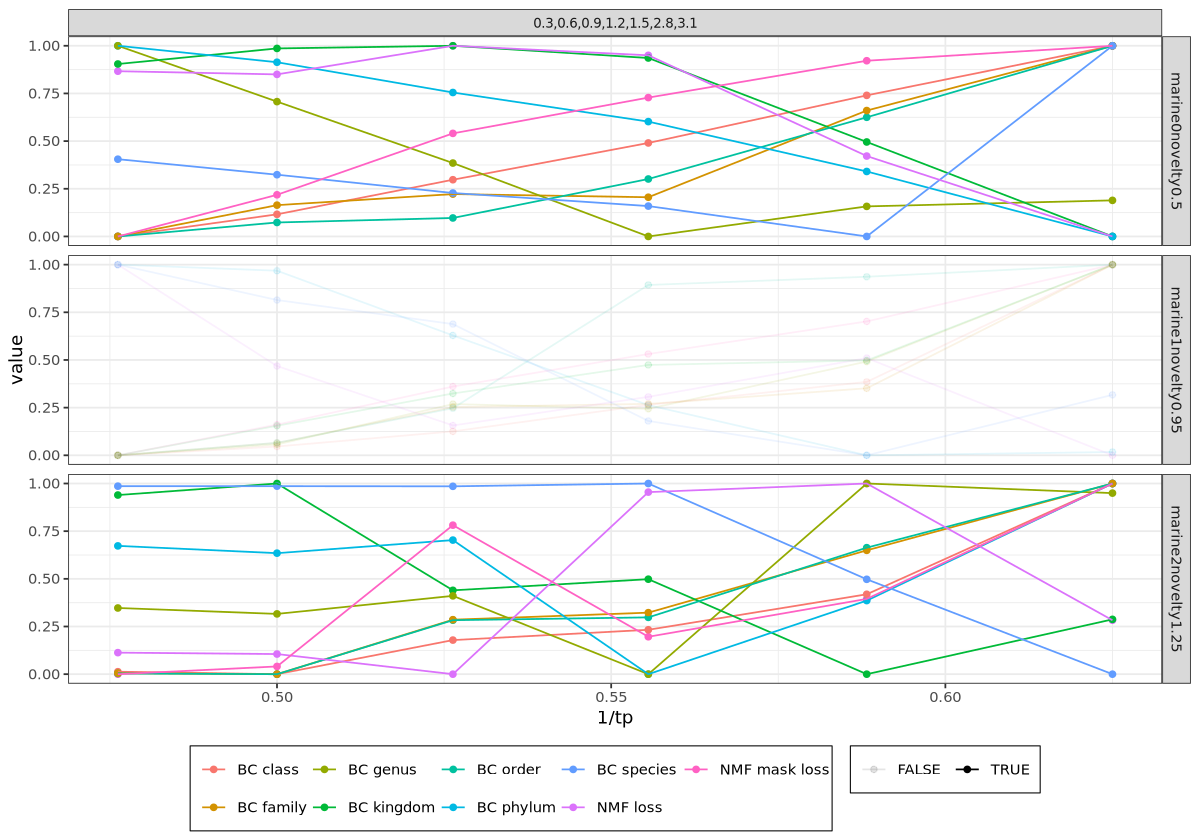

In [ ]:
s2p = make_groups(scale(s2[setp == 1 & (!startsWith(metric, "BC") | endsWith(metric, "kingdom") | endsWith(metric, "phylum"))]), "tp")
plot_rank(s2p, "tp")